Intro to SpatialData
https://spatialdata.scverse.org/en/latest/tutorials/notebooks/notebooks/examples/intro.html

to run the spatialdata , at least python 3.12 is needed.

Spatial Transcriptomics Workflow & Concepts
1. Technologies Overview 🔬
10x Xenium (In Situ Hybridization): A targeted approach looking for a specific, pre-defined panel of genes with precise single-molecule resolution. It requires a massive upfront capital cost for the hardware but offers a much lower running cost per sample.

Visium HD (Spatial Barcoding): Captures the whole transcriptome using a pre-printed grid of 2x2 µm squares (bins), each containing a unique chemical barcode. The initial hardware setup is cheaper, but the per-sample sequencing cost is extremely high due to the massive volume of data generated.

2. Staining and Tissue Preservation 🎨
The RNA Challenge: RNA is highly fragile. Tissues must be rapidly fixed to freeze RNA in place and processed in strictly RNase-free environments to prevent degradation during staining.

H&E Staining (Morphology): Excellent for viewing overall tissue architecture and necrotic regions, but lacks the specificity to reliably distinguish between different immune cell subtypes.

Immunofluorescence (IF): Uses fluorescently tagged antibodies to identify exact cell identities. It is physically limited to about 3 to 6 markers per slice due to the spectral overlap of light wavelengths.

3. The Visium HD Physical Workflow 🧬
Step-by-Step Pipeline: Section tissue ➡️ Fix ➡️ Stain (H&E or IF) ➡️ Image ➡️ Permeabilize (RNA drops into bins) ➡️ Barcode ➡️ Library Preparation (Convert unstable RNA to stable cDNA) ➡️ Sequence.

4. Data Integration & Computational Challenges 💻
The Goal: Overlaying the optical image layer (protein/cell identity) with the spatial barcode layer (transcriptome) to connect physical cell locations with their active gene expression pathways.

The Deconvolution Problem: The 2x2 µm bins are a rigid grid that ignores biological cell boundaries. A bin sitting perfectly on the border between an HEV-infected hepatocyte and an infiltrating T-cell will capture a mixed "soup" of RNA from both cells.

# Environment Setup Notes — SpatialData on Leine HPC

## The problem

Running `sd.read_zarr("mouse_liver.zarr")` failed with `PathNotFoundError`, and
after fixing the path, plotting failed with
`TypeError: AnnData.__init__() got an unexpected keyword argument 'dtype'`.

Three separate issues were tangled together:

1. **Wrong path.** The tutorial uses `mouse_liver.zarr`, but the downloaded store
   is named `data.zarr` and sits in `mouse_liver_spatialdata/`.
2. **Zarr v2 vs v3.** The store contains `zarr.json` = **Zarr v3 format**. The old
   env had `zarr 2.18.2` on **Python 3.9**, which cannot read v3 stores. `zarr>=3`
   requires Python >= 3.11, so the env itself had to be rebuilt.
3. **spatialdata-plot points bug.** `render_points()` failed with
   `TypeError: AnnData.__init__() got an unexpected keyword argument 'dtype'`.
   This was an **upstream bug already fixed in the repo but not yet released**
   to PyPI (0.4.0 was the latest release). Downgrading anndata does not help —
   `dtype` was removed before 0.11. Fix: install spatialdata-plot from GitHub.

## What I did

### 1. Diagnosed the path (not the format) first

```python
import os
print(os.path.exists(data_path))
print(os.listdir(os.path.dirname(data_path)))
```

### 2. Built a new environment (Leine has no Python module and no conda)

```bash
# Miniforge installs into $HOME — no admin rights needed
cd ~
rm -rf ~/miniforge3                     # installer refuses if the dir exists
wget "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh" -O miniforge.sh
bash miniforge.sh -b -p ~/miniforge3
~/miniforge3/bin/conda init bash
# close and REOPEN the terminal -> prompt shows (base)

conda create -n spatial312 python=3.12 -y
conda activate spatial312
pip install -U spatialdata "zarr>=3" scanpy spatialdata-io spatialdata-plot ipykernel
```

### 3. Pointed VS Code at the new env

`Ctrl+Shift+P` -> **Python: Select Interpreter** ->
`/hpc/leinehome/ghahramm/miniforge3/envs/spatial312/bin/python`
Then **Restart the kernel**. New terminals then auto-activate `(spatial312)`.

### 4. Fixed the points renderer by installing from source

```bash
conda activate spatial312
pip install git+https://github.com/scverse/spatialdata-plot.git
# -> spatialdata-plot 0.4.1.dev43+g076eeaca6, anndata back to 0.13.2
```

Restart the kernel afterwards. Both now work:

```python
sdata.pl.render_images("raw_image", cmap="gray").pl.show()
sdata.pl.render_points("transcripts", color="gene", groups="Vwf", palette="red").pl.show()
```

### 5. Snapshotted the working env

```bash
conda activate spatial312
pip freeze > ~/envs_spatial312_requirements.txt
```

## Checklist for next time

Work through these in order — each one rules out a whole class of failure.

| Symptom | Check | Fix |
|---|---|---|
| `PathNotFoundError` | `os.path.exists(data_path)` | Fix the path first — don't assume a format problem |
| Path exists but still fails | `os.listdir(data_path)` | `zarr.json` = v3, needs `zarr>=3`; `.zgroup` = v2 |
| `zarr>=3` won't install | `python --version` | zarr 3 needs Python >= 3.11 — rebuild the env |
| `command not found` after install | Prompt shows `(base)`? | `conda activate <env>`, or reopen the terminal |
| Version change has no effect | Compare `sys.executable` (notebook) vs `which python` (terminal) | Same env? Then **restart the kernel** — upgrading on disk doesn't reload an imported module |
| `unexpected keyword argument` | `pip list --outdated` | If nothing is outdated, it's an upstream bug — work around it, don't downgrade blindly |

## Traps that cost the most time

- **Shell vs Python.** `conda`, `pip`, `ls`, `cd` go in the **terminal**.
  `import`, `print()`, `=` go in a **cell**. In a cell, use `%pip` (magic), never bare `pip`.
- **Always check the prompt prefix.** `(spatial312)` vs `(base)` — several `pip install`
  commands silently went into the wrong env because of this.
- **Skip tutorial `%pip install` cells that pin old versions.** The SpatialData intro
  notebook has a cell installing `anndata==0.9.1` as a legacy workaround. On a modern
  env it *creates* the problem it was written to solve. Delete it.
- **Restart the kernel after any install.** Python keeps using whatever was imported
  at kernel start.
- **Check `main` before working around a bug.** The points renderer was already
  fixed upstream; only the PyPI release lagged. `pip install git+<repo-url>`
  settles this in under a minute and is worth trying before writing a workaround.

In [1]:
import spatialdata as sd, zarr
import spatialdata_plot  

/hpc/leinehome/ghahramm/miniforge3/envs/spatial312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = "/hpc/leinehome/ghahramm/tutorials/spatial/mouse_liver_spatialdata/data.zarr"
sdata = sd.read_zarr(data_path)
sdata

no parent found for <ome_zarr.reader.Label object at 0x7f7e29573260>: None


SpatialData object, with associated Zarr store: /hpc/leinehome/ghahramm/tutorials/spatial/mouse_liver_spatialdata/data.zarr
├── Images
│     └── 'raw_image': DataTree[cyx] (1, 6432, 6432), (1, 1608, 1608)
├── Labels
│     └── 'segmentation_mask': DataArray[yx] (6432, 6432)
├── Points
│     └── 'transcripts': DataFrame with shape: (1153548, 3) (2D points)
├── Shapes
│     └── 'nucleus_boundaries': GeoDataFrame shape: (3375, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (3375, 99)
with coordinate systems:
    ▸ 'global', with elements:
        raw_image (Images), segmentation_mask (Labels), transcripts (Points), nucleus_boundaries (Shapes)

In [3]:
sdata["raw_image"]

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 1, y: 6432, x: 6432)
│       Coordinates:
│         * c        (c) int64 8B 0
│         * y        (y) float64 51kB 0.5 1.5 2.5 3.5 ... 6.43e+03 6.43e+03 6.432e+03
│         * x        (x) float64 51kB 0.5 1.5 2.5 3.5 ... 6.43e+03 6.43e+03 6.432e+03
│       Data variables:
│           image    (c, y, x) uint16 83MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>
└── Group: /scale1
        Dimensions:  (c: 1, y: 1608, x: 1608)
        Coordinates:
          * c        (c) int64 8B 0
          * y        (y) float64 13kB 2.0 6.0 10.0 14.0 ... 6.422e+03 6.426e+03 6.43e+03
          * x        (x) float64 13kB 2.0 6.0 10.0 14.0 ... 6.422e+03 6.426e+03 6.43e+03
        Data variables:
            image    (c, y, x) uint16 5MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

In [4]:
sd.get_pyramid_levels(sdata["raw_image"], n=0)

<xarray.DataArray 'image' (c: 1, y: 6432, x: 6432)> Size: 83MB
dask.array<from-zarr, shape=(1, 6432, 6432), dtype=uint16, chunksize=(1, 256, 256), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) int64 8B 0
  * y        (y) float64 51kB 0.5 1.5 2.5 3.5 ... 6.43e+03 6.43e+03 6.432e+03
  * x        (x) float64 51kB 0.5 1.5 2.5 3.5 ... 6.43e+03 6.43e+03 6.432e+03
Attributes:
    transform:  {'global': Identity }

In [5]:
sd.models.get_axes_names(sdata["raw_image"])

('c', 'y', 'x')

In [6]:
sd.models.get_channel_names(sdata["raw_image"])

[0]

so from above outputs we get that our data set had only one channel of DAPI staining and also since it is unit16 so we have intensity between 0 to 65535. 

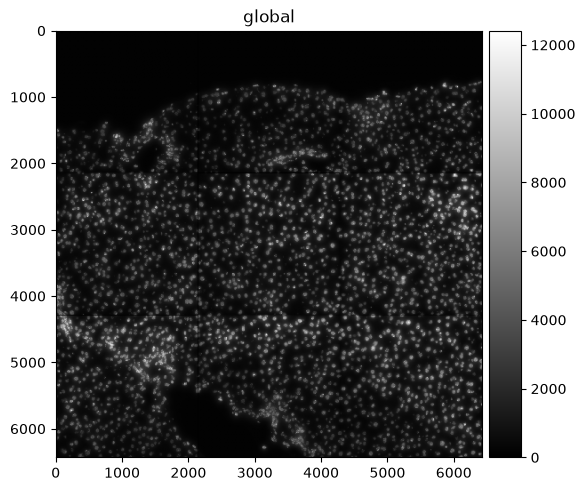

In [7]:
sdata.pl.render_images("raw_image", cmap="gray").pl.show()

Points

In [8]:
sdata["transcripts"]

,x,y,gene
npartitions=1,,,
,float64,float64,category[unknown]
,...,...,...


In [9]:
sdata["transcripts"].compute()

,x,y,gene
0,433.0,1217.0,Adgre1
1,151.0,1841.0,Adgre1
2,139.0,1983.0,Adgre1
3,1349.0,1601.0,Adgre1
4,784.0,1732.0,Adgre1
...,...,...,...
1998863,5743.0,5233.0,Lyve1
1998864,5721.0,4581.0,Lyve1
1998865,5807.0,4842.0,Lyve1
1998866,5843.0,5309.0,Lyve1


/tmp/ipykernel_2970877/3292649160.py:3: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  import anndata; print(anndata.__version__)   # must show 0.11.4


0.13.2


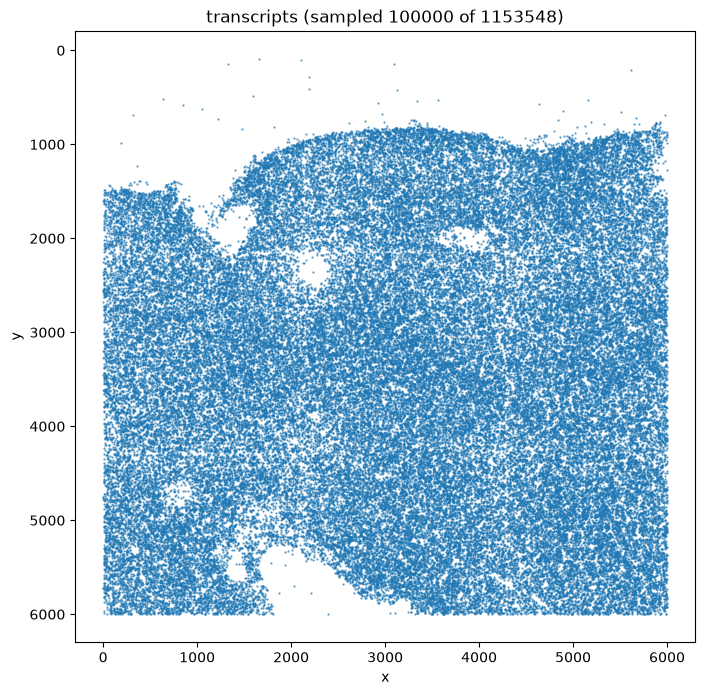

In [10]:
import numpy as np

import anndata; print(anndata.__version__)   # must show 0.11.4
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

pts = sdata["transcripts"].compute()
sample = pts.sample(n=min(len(pts), 100_000), random_state=0)

plt.figure(figsize=(8, 8))
plt.scatter(sample["x"], sample["y"], s=0.5, alpha=0.6)
plt.gca().invert_yaxis()
plt.gca().set_aspect("equal")
plt.xlabel("x"); plt.ylabel("y")
plt.title(f"transcripts (sampled {len(sample)} of {len(pts)})")
plt.show()

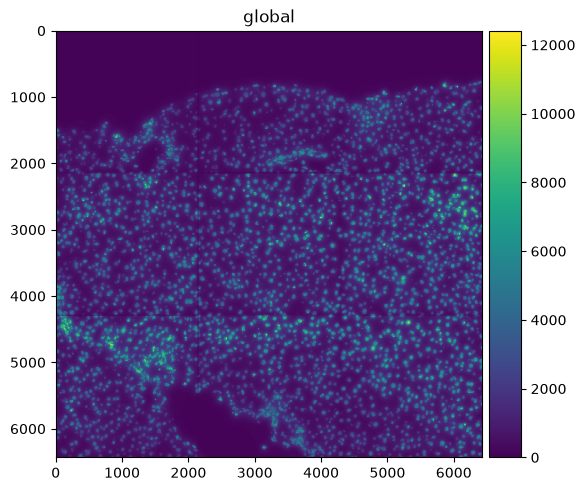

In [11]:
sdata.pl.render_images("raw_image").pl.show()

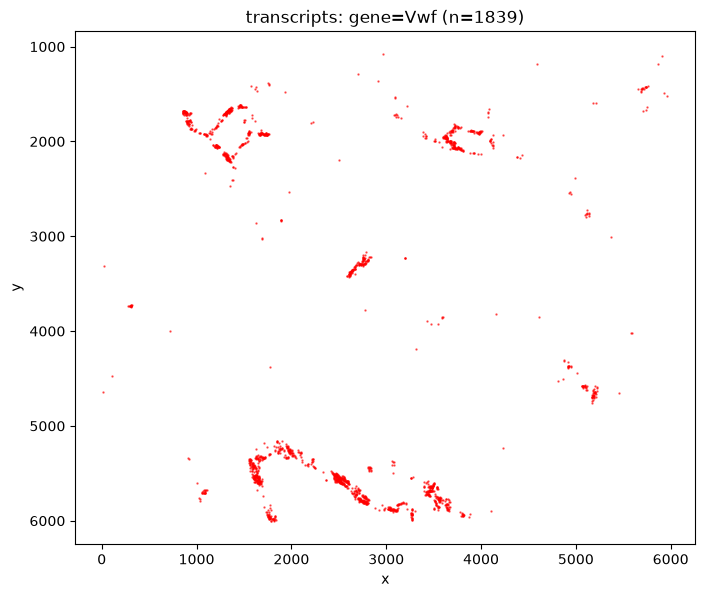

In [12]:
# Workaround for spatialdata-plot bug: plot points with matplotlib instead of sdata.pl.render_points
group = "Vwf"
color = "red"

df = pts  # pts already computed in the notebook
mask = df["gene"] == group
sub = df[mask]

if sub.empty:
    print(f"No points found for gene '{group}'")
else:
    xcol, ycol = "x", "y"
    sample_sub = sub.sample(n=min(len(sub), 100_000), random_state=0)
    plt.figure(figsize=(8, 8))
    plt.scatter(sample_sub[xcol], sample_sub[ycol], c=color, s=0.5, alpha=0.6)
    plt.gca().invert_yaxis()
    plt.gca().set_aspect("equal")
    plt.xlabel(xcol); plt.ylabel(ycol)
    plt.title(f"transcripts: gene={group} (n={len(sub)})")
    plt.show()

both of the codes working with different aproches

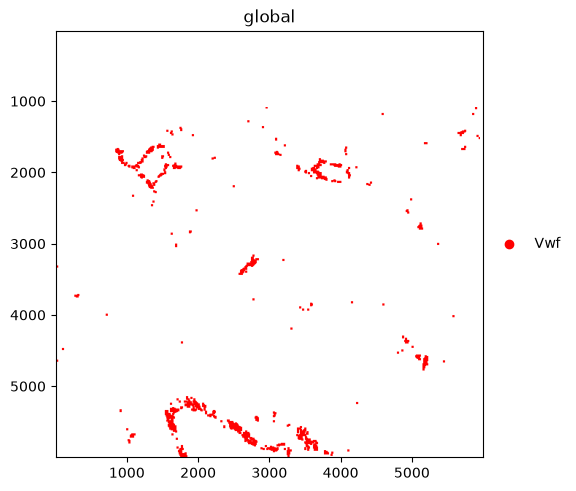

In [13]:
sdata.pl.render_points("transcripts", color="gene", groups="Vwf", palette="red").pl.show()

Shapes

In [14]:
sdata["nucleus_boundaries"]

,geometry
cell_ID,
99,"POLYGON ((6277 798, 6277 799, 6272 799, 6272 8..."
142,"POLYGON ((6427 6123, 6423 6123, 6423 6124, 641..."
208,"POLYGON ((3747 858, 3747 859, 3746 859, 3746 8..."
235,"POLYGON ((752 6144, 752 6145, 763 6145, 763 61..."
336,"POLYGON ((5174 935, 5174 936, 5172 936, 5172 9..."
...,...
7652,"POLYGON ((1094 6028, 1094 6029, 1091 6029, 109..."
7680,"POLYGON ((1324 6063, 1324 6064, 1320 6064, 132..."
7694,"POLYGON ((1692 6063, 1692 6064, 1686 6064, 168..."


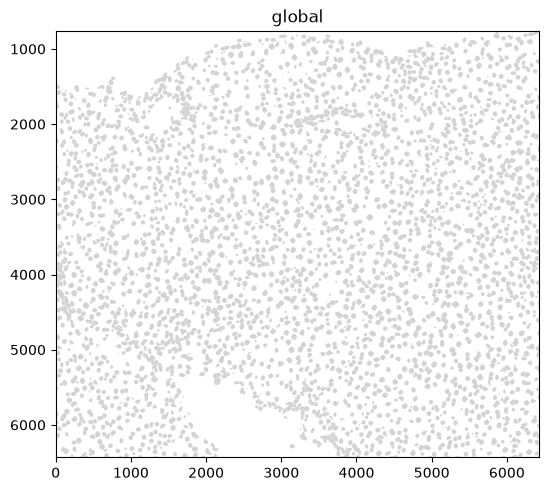

In [15]:
sdata.pl.render_shapes("nucleus_boundaries").pl.show()

tables

In [16]:
sdata["table"]

AnnData object with n_obs × n_vars = 3375 × 99
    obs: 'cell_ID', 'fov_labels', 'annotation'
    uns: 'annotation_colors', 'spatialdata_attrs'
    obsm: 'spatial'
    layers: None (.X)

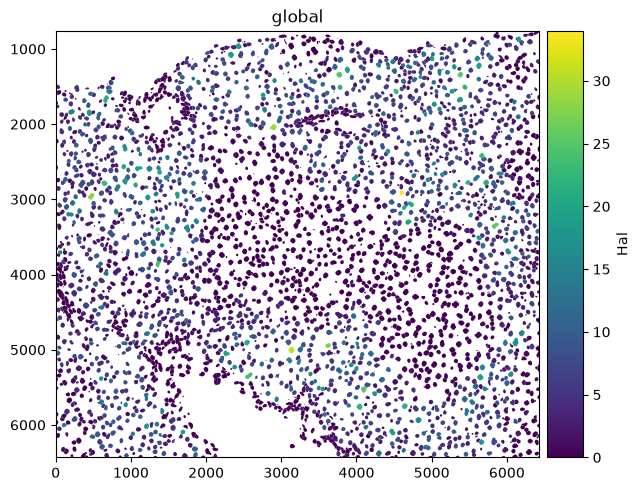

In [17]:
sdata.pl.render_shapes("nucleus_boundaries", color="Hal").pl.show()

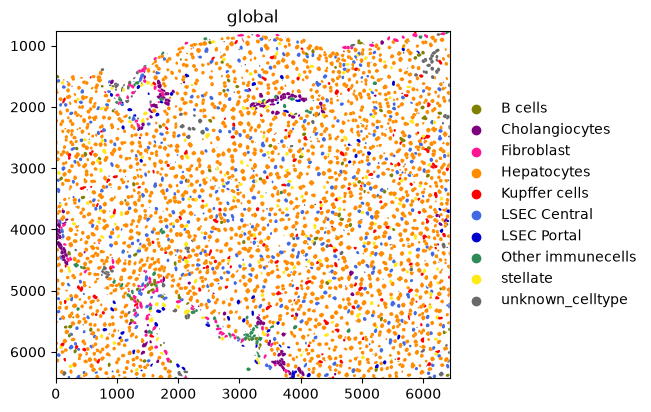

In [18]:
sdata.pl.render_shapes("nucleus_boundaries", color= "annotation").pl.show()

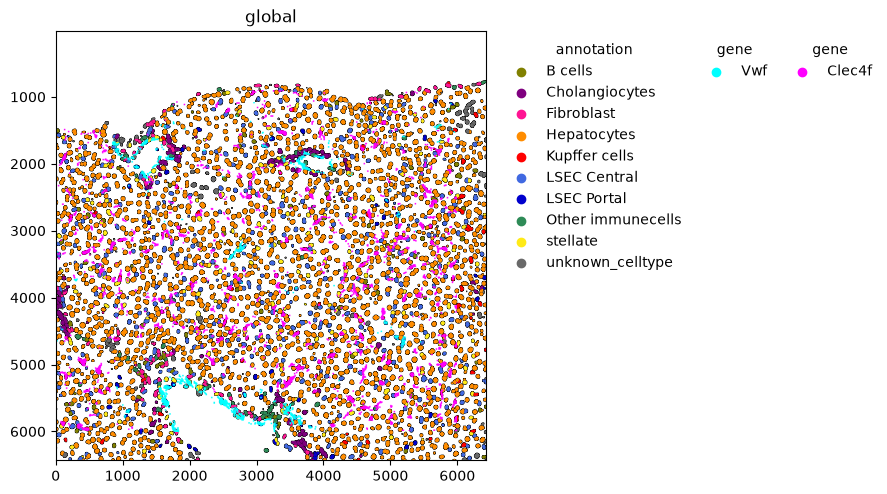

In [19]:
(
    sdata.pl.render_shapes(
        "nucleus_boundaries",
        color="annotation",
        outline_alpha=1.0,
        outline_width=0.5,
    )
    .pl.render_points(
        "transcripts",
        color="gene",
        groups="Vwf",
        palette="cyan",
    )
    .pl.render_points(
        "transcripts",
        color="gene",
        groups="Clec4f",
        palette="magenta",
    )
    .pl.show(figsize=(8, 8))
)

Spatial Querying and Subsetting


In [20]:
sd.get_extent(sdata)

{'y': (np.float64(0.0), np.float64(6432.0)),
 'x': (np.float64(0.0), np.float64(6432.0))}

In [21]:
crop_sdata1 = sd.bounding_box_query(
    sdata,
    axes=("y", "x"),
    min_coordinate=[1000, 1000],
    max_coordinate=[2000, 2000],
    target_coordinate_system="global"
)
crop_sdata1 

SpatialData object
├── Images
│     └── 'raw_image': DataTree[cyx] (1, 1000, 1000), (1, 250, 250)
├── Labels
│     └── 'segmentation_mask': DataArray[yx] (1000, 1000)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 3) (2D points)
├── Shapes
│     └── 'nucleus_boundaries': GeoDataFrame shape: (96, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (96, 99)
with coordinate systems:
    ▸ 'global', with elements:
        raw_image (Images), segmentation_mask (Labels), transcripts (Points), nucleus_boundaries (Shapes)

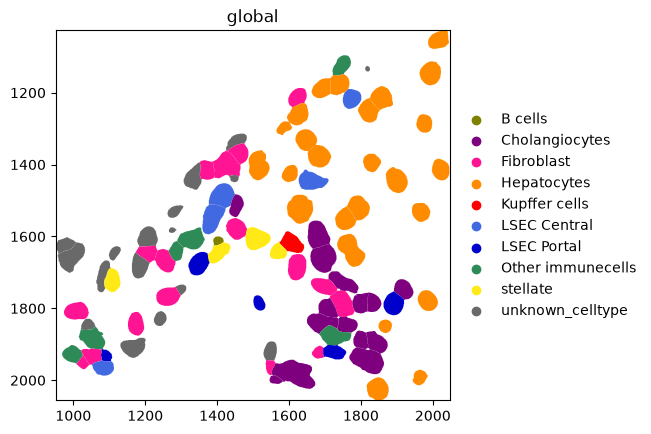

In [22]:
crop_sdata1.pl.render_shapes("nucleus_boundaries", color="annotation").pl.show()

In [25]:
from shapely import Polygon

polygon= Polygon([(1000, 1000), (1500, 1000), (2000, 1500), (1500, 2000)])
crop_sdata2 = sd.polygon_query(sdata, polygon, target_coordinate_system="global")
crop_sdata2 

SpatialData object
├── Images
│     └── 'raw_image': DataTree[cyx] (1, 1000, 1000), (1, 250, 250)
├── Labels
│     └── 'segmentation_mask': DataArray[yx] (1000, 1000)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 3) (2D points)
├── Shapes
│     └── 'nucleus_boundaries': GeoDataFrame shape: (45, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (45, 99)
with coordinate systems:
    ▸ 'global', with elements:
        raw_image (Images), segmentation_mask (Labels), transcripts (Points), nucleus_boundaries (Shapes)

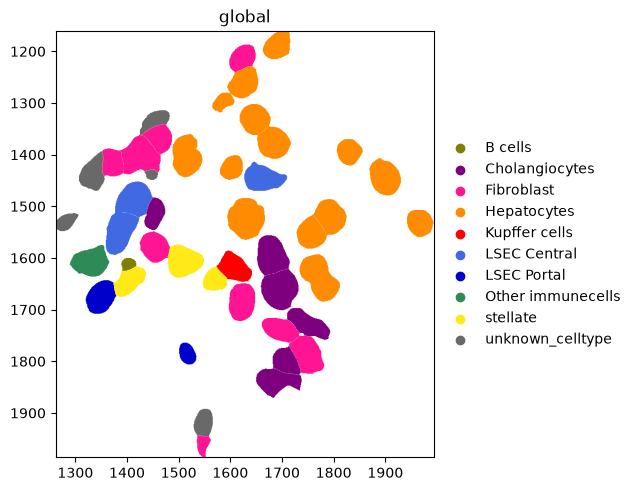

In [26]:
crop_sdata2.pl.render_shapes("nucleus_boundaries", color="annotation").pl.show()

In [32]:
from pathlib import Path
from tempfile import TemporaryDirectory

tmpdir = TemporaryDirectory()
crop_sdata2.write(Path(tmpdir.name) / "crop.zarr")
tmpdir.cleanup()

/hpc/leinehome/ghahramm/miniforge3/envs/spatial312/lib/python3.12/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Identity is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
/hpc/leinehome/ghahramm/miniforge3/envs/spatial312/lib/python3.12/site-packages/dask/dataframe/io/parquet/arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Identity is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)


In [34]:
cell_types = sd.get_values("annotation", crop_sdata2["table"])["annotation"]

In [35]:
crop_sdata2["cholangiocytes"] = crop_sdata2["nucleus_boundaries"][cell_types == "Cholangiocytes"]

/hpc/leinehome/ghahramm/miniforge3/envs/spatial312/lib/python3.12/site-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


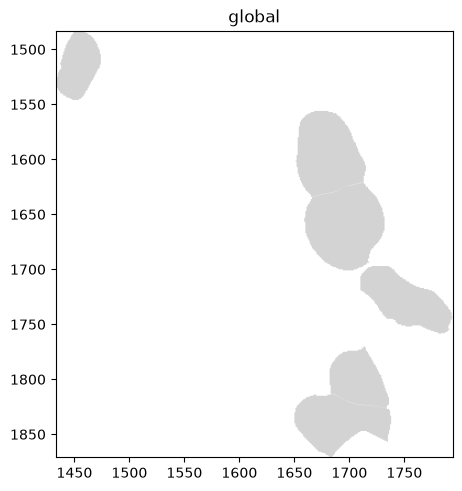

In [36]:
crop_sdata2.pl.render_shapes("cholangiocytes").pl.show()

In [40]:
from pathlib import Path
import shutil

output_path = Path.cwd() / "crop.zarr"

if output_path.exists():
    shutil.rmtree(output_path)

crop_sdata2.write(output_path, overwrite=True)
# `write_element()` can fail when writing back into the currently attached Zarr store.
# Write the full SpatialData object to a fresh output path instead.
updated_path = output_path.with_name("crop_with_cholangiocytes.zarr")

if updated_path.exists():
    shutil.rmtree(updated_path)

crop_sdata2.write(updated_path, overwrite=True)

/hpc/leinehome/ghahramm/miniforge3/envs/spatial312/lib/python3.12/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Identity is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
/hpc/leinehome/ghahramm/miniforge3/envs/spatial312/lib/python3.12/site-packages/dask/dataframe/io/parquet/arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Identity is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)
/hpc/leinehome/ghahramm/miniforge3/envs/spatial312/lib/python3.12/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Identity is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
/hpc/leinehome/ghahramm/miniforge3/envs/spatial312/lib/python3.12/site-packages/dask/dataframe/io/parquet/arrow.py:824: Us

In [42]:
tmpdir.cleanup()